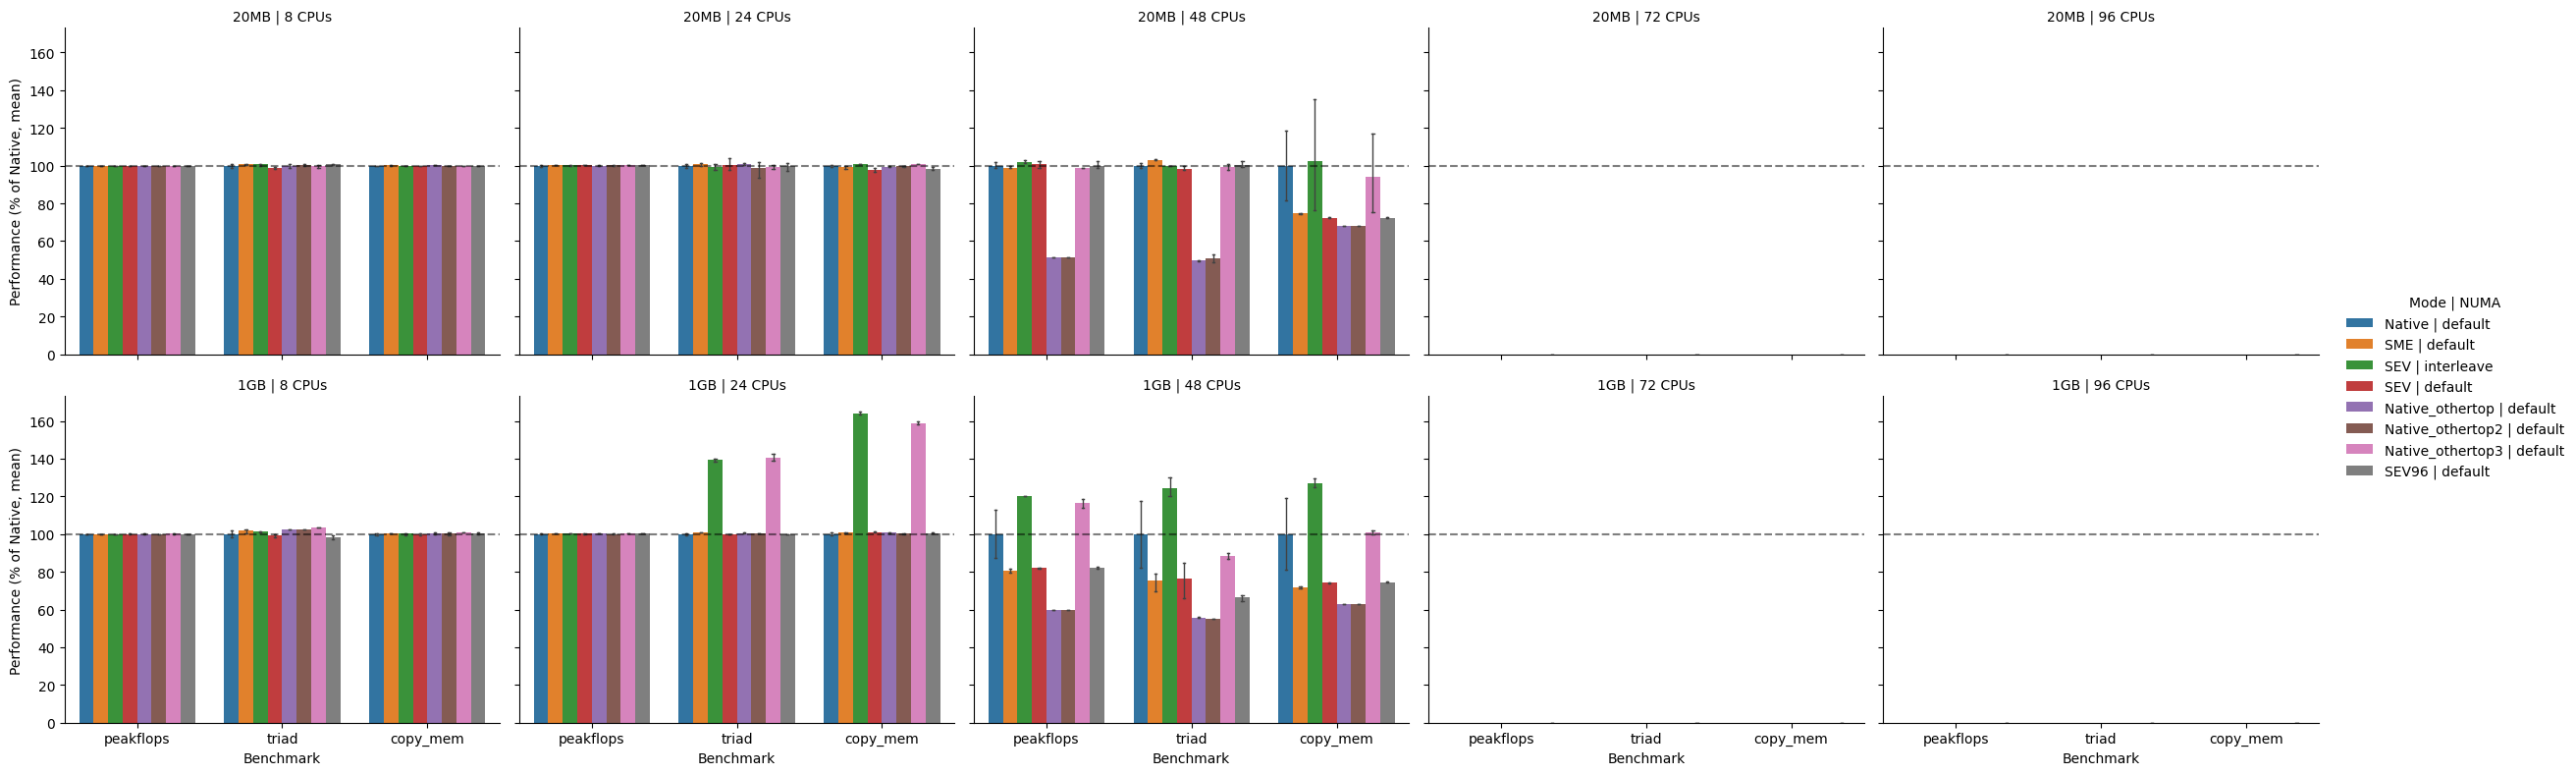

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Daten laden
df = pd.read_csv("output2.csv")
df["MBps"] = pd.to_numeric(df["MBps"], errors="coerce")

# 2) Aggregationsfunktion für Balkenhöhe
agg_func = "mean"   # alternativ: "median"
estimator = np.mean if agg_func == "mean" else np.median

# 3) Baseline aus Native | default (Mittelwert je Bench/Size/CPUs)
baseline = (
    df[(df["Mode"] == "Native96") & (df["NUMA"] == "default")]
    .groupby(["Bench", "Size", "CPUs"], as_index=False)["MBps"]
    .mean()
    .rename(columns={"MBps": "MBps_baseline"})
)

# 4) Prozent relativ zur Baseline (pro Run, damit Error Bars möglich sind)
plot_df = df.merge(baseline, on=["Bench", "Size", "CPUs"], how="left")
plot_df["Percent_of_Native"] = (
    (plot_df["MBps"] / plot_df["MBps_baseline"]) * 100
).where(plot_df["MBps_baseline"] > 0, 0).fillna(0)

plot_df["Mode_NUMA"] = plot_df["Mode"] + " | " + plot_df["NUMA"]

# 5) Plot mit Error Bars
g = sns.catplot(
    data=plot_df,
    kind="bar",
    x="Bench",
    y="Percent_of_Native",
    hue="Mode_NUMA",
    col="CPUs",
    row="Size",
    estimator=estimator,
    errorbar=("ci", 95),   # alternativ: "sd" oder ("se", 1)
    capsize=0.12,
    err_kws={"linewidth": 1},
    height=4,
    aspect=1.2,
    palette="tab10"
)

for ax in g.axes.flat:
    ax.axhline(100, ls="--", color="black", alpha=0.5)

g.set_axis_labels("Benchmark", f"Performance (% of Native, {agg_func})")
g.set_titles("{row_name} | {col_name} CPUs")
g._legend.set_title("Mode | NUMA")

plt.show()
